# 02 · Probabilidad para decisiones

**RA1 · probabilidad, Bayes y distribuciones.** Resolver incertidumbre con frecuencias, eventos condicionados y modelos explícitos. Tiempo sugerido: dos sesiones.

**Caso:** ComercioSur, datos simulados. Ejecutar en orden con kernel activo. Cada ejercicio exige una interpretación y un límite; consultar [manual](../material_propio/EBA_manual_cientifico.html) y [guía](../guia_maestra_eba.html). El curso presupone manejo elemental de tablas de Fundamentos. No instalar paquetes desde las celdas.

### Antes de ejecutar

Núcleo · 90 min guiados + 30 min autónomos orientativos.

**Objetivo:** Construir un modelo probabilístico cuyo soporte y supuestos sean explícitos.

**Preparación:** Módulo 01; porcentajes y tablas de frecuencias.

**Ejemplo de referencia:** En 10000 casos, prevalencia 2%, sensibilidad 90% y especificidad 95% dan 180 alertas verdaderas y 490 falsas.

**Práctica:** Modificar la prevalencia y una meta binomial; explicar independencia y tasa base.

**Criterio de logro:** Calcular e interpretar el posterior 180/670 y explicar por qué no equivale a sensibilidad.

**Distribución orientativa:** explicación 30 min; práctica guiada 60 min; trabajo autónomo 30 min. Ajustar tras una clase piloto.

[Guía y secuencia](../guia_maestra_eba.html#ruta-aprendizaje) · [Fundamento del manual](../material_propio/EBA_manual_cientifico.html#sec-probabilidad)

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import ipywidgets as widgets
from IPython.display import display, Markdown

RAIZ = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "_transversal/datos").is_dir())
sys.path.insert(0, str(RAIZ / "02_Estadistica_Business_Analytics/reproducibilidad"))
from eba_recursos import *

df = pedidos()
plt.rcParams.update(
    {"figure.figsize": (7, 3.4), "axes.spines.top": False, "axes.spines.right": False}
)

<a id="eventos"></a>
## Reglas de probabilidad

Con resolución R y campaña B: P(R∩B)=P(R|B)P(B); P(R∪B)=P(R)+P(B)−P(R∩B). No asumir independencia entre tratamiento y resultado.

In [2]:
R = df.resuelto.eq(1)
B = df.campana.eq("B")
display(
    pd.Series(
        {
            "P(R)": R.mean(),
            "P(B)": B.mean(),
            "P(R y B)": (R & B).mean(),
            "P(R|B)": R[B].mean(),
            "P(R o B)": (R | B).mean(),
        }
    )
)
assert np.isclose((R & B).mean(), R[B].mean() * B.mean())

P(R)        0.755000
P(B)        0.348333
P(R y B)    0.266667
P(R|B)      0.765550
P(R o B)    0.836667
dtype: float64

<a id="bayes"></a>
## Alerta de riesgo: frecuencias naturales

Ejemplo separado: prevalencia 2%, sensibilidad 90%, especificidad 95%. En 10.000 casos se esperan 180 verdaderos positivos y 490 falsos positivos. Una alerta positiva implica aproximadamente 26,9% de riesgo bajo esos supuestos, no 90%. Los conteos esperados pueden no ser enteros al mover parámetros.

### Primero, la tabla de frecuencias

Separa población con/sin condición. Aplica sensibilidad solo a la primera y especificidad solo a la segunda.
El denominador de una alerta es VP+FP. Anticipa cómo cambiará el posterior antes de usar el control.

In [3]:
ejemplo_n = 10000
ejemplo_riesgo = ejemplo_n * 0.02
ejemplo_sin_riesgo = ejemplo_n - ejemplo_riesgo
ejemplo_vp = ejemplo_riesgo * 0.90
ejemplo_fn = ejemplo_riesgo - ejemplo_vp
ejemplo_vn = ejemplo_sin_riesgo * 0.95
ejemplo_fp = ejemplo_sin_riesgo - ejemplo_vn
display(
    pd.DataFrame(
        {"Alerta": [ejemplo_vp, ejemplo_fp], "Sin alerta": [ejemplo_fn, ejemplo_vn]},
        index=["Riesgo", "Sin riesgo"],
    )
)
ejemplo_posterior = ejemplo_vp / (ejemplo_vp + ejemplo_fp)
print("Posterior:", ejemplo_posterior)
assert np.isclose(ejemplo_posterior, bayes(0.02, 0.9, 0.95)["posterior"])

,Alerta,Sin alerta
Riesgo,180.0,20.0
Sin riesgo,490.0,9310.0


Posterior: 0.26865671641791045


In [4]:
@widgets.interact(
    prevalencia=widgets.FloatSlider(value=0.02, min=0.001, max=0.2, step=0.001),
    especificidad=widgets.FloatSlider(value=0.95, min=0.8, max=0.999, step=0.001),
)
def alertas(prevalencia, especificidad):
    b = bayes(prevalencia, 0.9, especificidad)
    print(
        f"VP esperados/10.000: {10000*b['positivos_verdaderos']:.1f}; FP: {10000*b['falsos_positivos']:.1f}; P(riesgo|alerta): {b['posterior']:.2%}"
    )

interactive(children=(FloatSlider(value=0.02, description='prevalencia', max=0.2, min=0.001, step=0.001), Floa…

<a id="discretas"></a>
## Bernoulli, binomial y Poisson

Bernoulli: resolución de un pedido. Binomial: número resuelto en n pedidos independientes con p constante. Poisson: número de llegadas con tasa constante y sucesos independientes; no asumirlo para congestión o ráfagas.

P(al menos 18 resueltos de 20), p=.8: 0.20608471894847402
P(más de 8 llegadas), lambda=5: 0.0680936347218484
Media/varianza binomial: (np.float64(16.0), np.float64(3.1999999999999975))


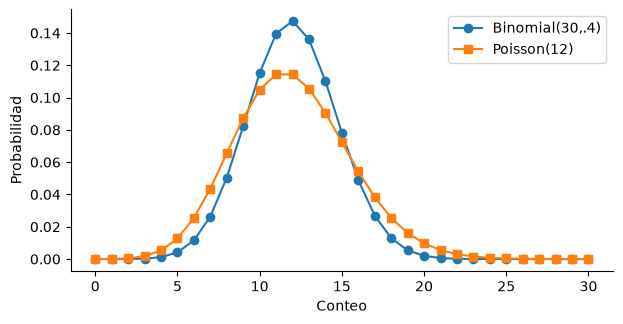

In [5]:
print("P(al menos 18 resueltos de 20), p=.8:", stats.binom.sf(17, 20, 0.8))
print("P(más de 8 llegadas), lambda=5:", stats.poisson.sf(8, 5))
print("Media/varianza binomial:", stats.binom.stats(20, 0.8))
k = np.arange(31)
plt.plot(k, stats.binom.pmf(k, 30, 0.4), "o-", label="Binomial(30,.4)")
plt.plot(k, stats.poisson.pmf(k, 12), "s-", label="Poisson(12)")
plt.xlabel("Conteo")
plt.ylabel("Probabilidad")
plt.legend()
plt.show()

<a id="continuas"></a>
## Normal, exponencial y uniforme

Normal para ruido simétrico; exponencial para espera bajo proceso de Poisson; uniforme como idealización acotada. En variables continuas P(X=x)=0 y el área, no la altura de la densidad, representa probabilidad. El ticket asimétrico no se vuelve normal por aumentar las filas.

P(tiempo > 50), N(40,7²): 0.07656372550983476
P(espera > 10), media=5: 0.1353352832366127
P(2<X<6), Uniforme(0,10): 0.39999999999999997


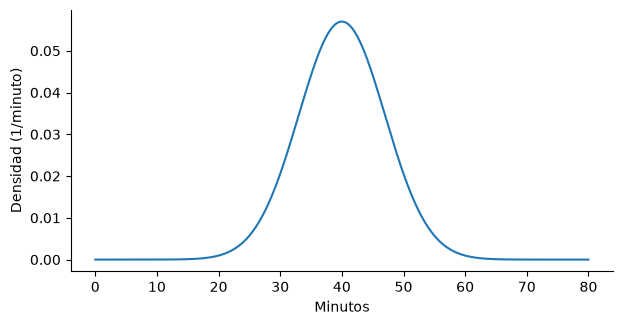

In [6]:
print("P(tiempo > 50), N(40,7²):", stats.norm.sf(50, loc=40, scale=7))
print("P(espera > 10), media=5:", stats.expon.sf(10, scale=5))
print("P(2<X<6), Uniforme(0,10):", stats.uniform.cdf(6, scale=10) - stats.uniform.cdf(2, scale=10))
x = np.linspace(0, 80, 400)
plt.plot(x, stats.norm.pdf(x, 40, 7))
plt.xlabel("Minutos")
plt.ylabel("Densidad (1/minuto)")
plt.show()

<a id="simulacion"></a>
## Simular para comprender y comprobar

La frecuencia converge a la probabilidad bajo el modelo; una simulación precisa puede representar mal el negocio si sus supuestos son falsos. Actividad: escoja un modelo para reclamos, espera y gasto; indique una razón para rechazarlo.

In [7]:
@widgets.interact(
    p=widgets.FloatSlider(value=0.8, min=0.05, max=0.95, step=0.05),
    n=widgets.IntSlider(value=20, min=5, max=100, step=5),
)
def simular(p, n):
    rng = np.random.default_rng(SEMILLA)
    x = rng.binomial(n, p, 10000)
    print(
        f"Media empírica {x.mean():.3f} / teórica {n*p:.3f}; varianza empírica {x.var():.3f} / teórica {n*p*(1-p):.3f}"
    )
    plt.hist(x, bins=np.arange(n + 2) - 0.5, density=True)
    plt.xlabel("Éxitos")
    plt.ylabel("Frecuencia relativa")
    plt.show()

interactive(children=(FloatSlider(value=0.8, description='p', max=0.95, min=0.05, step=0.05), IntSlider(value=…

## Comprobación y entrega

Responda la autoevaluación y complete la actividad del último bloque. Entregue objetivo, método, supuesto, resultado con unidades y decisión condicionada. Las soluciones orientadoras permiten estudiar, pero no sustituyen su interpretación.

In [8]:
auto_02 = pregunta(
    "¿Sensibilidad de 90% significa P(enfermedad o riesgo|positivo)=90%?",
    "Sí, son la misma probabilidad",
    "No, hay que incorporar prevalencia y falsos positivos",
    "Bayes invierte el condicionamiento mediante la probabilidad marginal de la alerta.",
    tercera="Solo hace falta conocer la especificidad; la prevalencia se cancela",
)
display(auto_02)

## Práctica de transferencia 02

Construye una tabla 2×2 para 10.000 alertas potenciales con prevalencia 3%, sensibilidad 85% y especificidad 94%. Calcula P(riesgo|alerta) sin llamar al helper. Elige una distribución para llegadas y justifica un supuesto que podría fallar.

**Entrega:** hipótesis previa, cálculo con unidades, interpretación y límite. Completa tu respuesta antes de consultar la [pauta docente](../material_propio/PAUTA_DOCENTE.md#nb02).

**Discusión:** ¿Por qué una alerta no equivale a una clasificación confirmada?

### Tu resolución

Edita esta celda: escribe tu hipótesis, procedimiento, resultado, interpretación y una comprobación. Adjunta tu código o gráfico si la actividad lo requiere.

**Auto-revisión:** ¿usé la población correcta?, ¿declaré unidades y supuestos?, ¿mi evidencia permite esa conclusión?